In [ ]:
!unzip AMGPRA.zip

Archive:  AMGPRA.zip
   creating: AMGPRA/
  inflating: AMGPRA/models.py        
  inflating: __MACOSX/AMGPRA/._models.py  
  inflating: AMGPRA/__init__.py      
  inflating: __MACOSX/AMGPRA/.___init__.py  
  inflating: AMGPRA/core.py          
  inflating: __MACOSX/AMGPRA/._core.py  
   creating: AMGPRA/__pycache__/
  inflating: __MACOSX/AMGPRA/.___pycache__  
  inflating: AMGPRA/learning.py      
  inflating: __MACOSX/AMGPRA/._learning.py  
  inflating: AMGPRA/__pycache__/core.cpython-312.pyc  
  inflating: __MACOSX/AMGPRA/__pycache__/._core.cpython-312.pyc  
  inflating: AMGPRA/__pycache__/models.cpython-312.pyc  
  inflating: __MACOSX/AMGPRA/__pycache__/._models.cpython-312.pyc  
  inflating: AMGPRA/__pycache__/__init__.cpython-312.pyc  
  inflating: __MACOSX/AMGPRA/__pycache__/.___init__.cpython-312.pyc  
  inflating: AMGPRA/__pycache__/learning.cpython-312.pyc  
  inflating: __MACOSX/AMGPRA/__pycache__/._learning.cpython-312.pyc  


In [ ]:
!pip install smt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00


---


--- RUN AMGPRA 1/5 ---
Iter 00 | Cost: 6.60 | Pf: 6.1600e-02 | max(EFF): 3.58e+00
Iter 10 | Cost: 7.60 | Pf: 5.0350e-02 | max(EFF): 8.10e-01
Iter 20 | Cost: 8.60 | Pf: 4.5190e-02 | max(EFF): 7.97e-03
Iter 30 | Cost: 10.60 | Pf: 3.7111e-02 | max(EFF): 1.52e-03
--- Convergence atteinte à l'itération 35 ! ---

--- RUN AMGPRA 2/5 ---
Iter 00 | Cost: 6.60 | Pf: 3.1000e-03 | max(EFF): 5.76e-02
Iter 10 | Cost: 7.60 | Pf: 3.6036e-02 | max(EFF): 2.13e+00
Iter 20 | Cost: 8.60 | Pf: 2.8858e-02 | max(EFF): 1.89e-02
Iter 30 | Cost: 9.60 | Pf: 2.8686e-02 | max(EFF): 1.84e-02
Iter 40 | Cost: 14.60 | Pf: 3.1526e-02 | max(EFF): 2.97e-04
--- Convergence atteinte à l'itération 40 ! ---

--- RUN AMGPRA 3/5 ---
Iter 00 | Cost: 6.60 | Pf: 5.3700e-01 | max(EFF): 2.15e-01
Iter 10 | Cost: 7.60 | Pf: 5.9059e-02 | max(EFF): 2.32e+00
Iter 20 | Cost: 8.60 | Pf: 5.8116e-02 | max(EFF): 5.87e-01
Iter 30 | Cost: 11.60 | Pf: 3.2096e-02 | max(EFF): 2.70e-01
Iter 40 | Cost: 18.60 | Pf: 3.2430e-02 | max(EFF): 2.52e-02
--

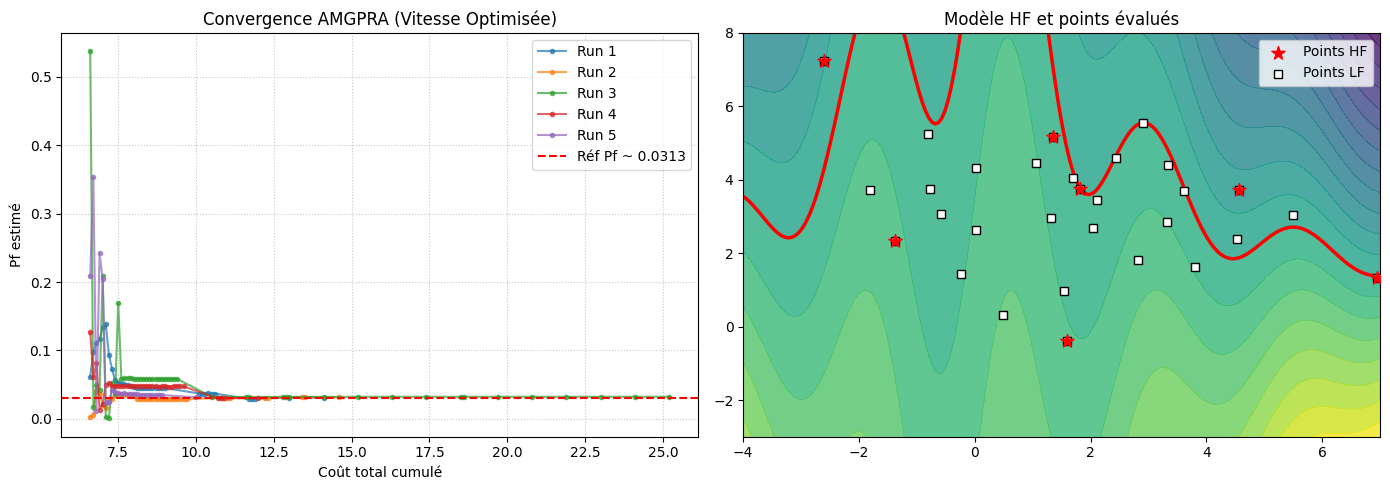

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")
from smt.applications import MFK
from smt.sampling_methods import LHS

# 5.1. Bi-fidelity model
def g_hf(x):
    return 2 - (x[:,0]**2 + 4)*(x[:,1] - 1)/20 + np.sin(2.5*x[:,0])
def g_lf(x):
    return g_hf(x) - np.sin(5*x[:,0]/22 + 5*x[:,1]/44 + 5/4)

if __name__ == "__main__":
    n_runs = 5
    n_train, n_eval = 10000, 1000000

    functions = [g_hf, g_lf]
    costs = [1.0, 0.1]
    xlimits = np.array([[-4.0, 7.0], [-2.0, 8.0]])

    all_pfs, all_costs = [], []
    all_pf_h, all_cost_h = [], []

    for run_idx in range(n_runs):
        print(f"\n--- RUN AMGPRA {run_idx + 1}/{n_runs} ---")
        S_train = np.column_stack([np.random.normal(1.5, 1.0, n_train), np.random.normal(2.5, 1.0, n_train)])

        solver = AMGPRA(functions, costs, xlimits, S_candidate=S_train, n_init=6, eff_stop=0.001)
        solver.run()

        S_eval = np.column_stack([np.random.normal(1.5, 1.0, n_eval), np.random.normal(2.5, 1.0, n_eval)])
        mu_eval, _ = solver.model.predict(S_eval)
        final_pf = np.sum(mu_eval <= 0) / n_eval

        all_pfs.append(final_pf)
        all_costs.append(solver.total_cost)
        all_pf_h.append(solver.pf_history)
        all_cost_h.append(solver.cost_history)
        last_solver = solver

    print("\n=========================================")
    print(f"Pf moyen   : {np.mean(all_pfs):.4e} (Réf Papier : ~3.14e-02)")
    print(f"Coût moyen : {np.mean(all_costs):.2f} (Réf Papier : ~12.58)")

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    for i in range(n_runs):
        plt.plot(all_cost_h[i], all_pf_h[i], marker='.', alpha=0.7, label=f'Run {i+1}')
    plt.axhline(y=0.0313, color='r', linestyle='--', label='Réf Pf ~ 0.0313')
    plt.xlabel('Coût total cumulé')
    plt.ylabel('Pf estimé')
    plt.title('Convergence AMGPRA (Vitesse Optimisée)')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()

    plt.subplot(1, 2, 2)
    X1, X2 = np.meshgrid(np.linspace(-4, 7, 200), np.linspace(-3, 8, 200))
    Z = g_hf(np.column_stack((X1.flatten(), X2.flatten()))).reshape(X1.shape)

    plt.contourf(X1, X2, Z, levels=20, cmap='viridis', alpha=0.8)
    plt.contour(X1, X2, Z, levels=[0], colors='red', linewidths=2.5)

    plt.scatter(last_solver.xt[0][:, 0], last_solver.xt[0][:, 1], color='red', marker='*', s=100, label='Points HF', zorder=4)
    plt.scatter(last_solver.xt[1][:, 0], last_solver.xt[1][:, 1], color='white', edgecolor='black', marker='s', s=30, label='Points LF', zorder=3)

    plt.xlim([-4, 7])
    plt.ylim([-3, 8])
    plt.title('Modèle HF et points évalués')
    plt.legend()
    plt.tight_layout()
    plt.show()


--- RUN AMGPRA 1/5 ---
Iter 00 | Cost: 6.66 | Pf: 6.7000e-03 | max(EFF): 3.08e+00
Iter 10 | Cost: 6.76 | Pf: 1.0110e-02 | max(EFF): 5.80e-01
Iter 20 | Cost: 6.86 | Pf: 1.1323e-02 | max(EFF): 2.35e-01
Iter 30 | Cost: 6.96 | Pf: 1.1234e-02 | max(EFF): 2.11e-02
Iter 40 | Cost: 7.16 | Pf: 6.4257e-03 | max(EFF): 2.37e-02
Iter 50 | Cost: 7.76 | Pf: 7.7789e-02 | max(EFF): 4.17e-02
Iter 60 | Cost: 8.56 | Pf: 7.8270e-02 | max(EFF): 1.10e-02
Iter 70 | Cost: 9.56 | Pf: 7.8046e-02 | max(EFF): 9.48e-03
Iter 80 | Cost: 11.66 | Pf: 2.9435e-02 | max(EFF): 1.60e-03
--- Convergence atteinte à l'itération 86 ! ---

--- RUN AMGPRA 2/5 ---
Iter 00 | Cost: 6.66 | Pf: 4.4130e-01 | max(EFF): 1.41e+00
Iter 10 | Cost: 6.76 | Pf: 5.9860e-02 | max(EFF): 1.07e+00
Iter 20 | Cost: 6.96 | Pf: 2.7555e-02 | max(EFF): 4.49e-01
Iter 30 | Cost: 7.46 | Pf: 1.6449e-02 | max(EFF): 1.37e-01
Iter 40 | Cost: 7.96 | Pf: 1.6365e-02 | max(EFF): 3.31e-02
Iter 50 | Cost: 9.56 | Pf: 3.0653e-02 | max(EFF): 1.43e-03
Iter 60 | Cost: 10

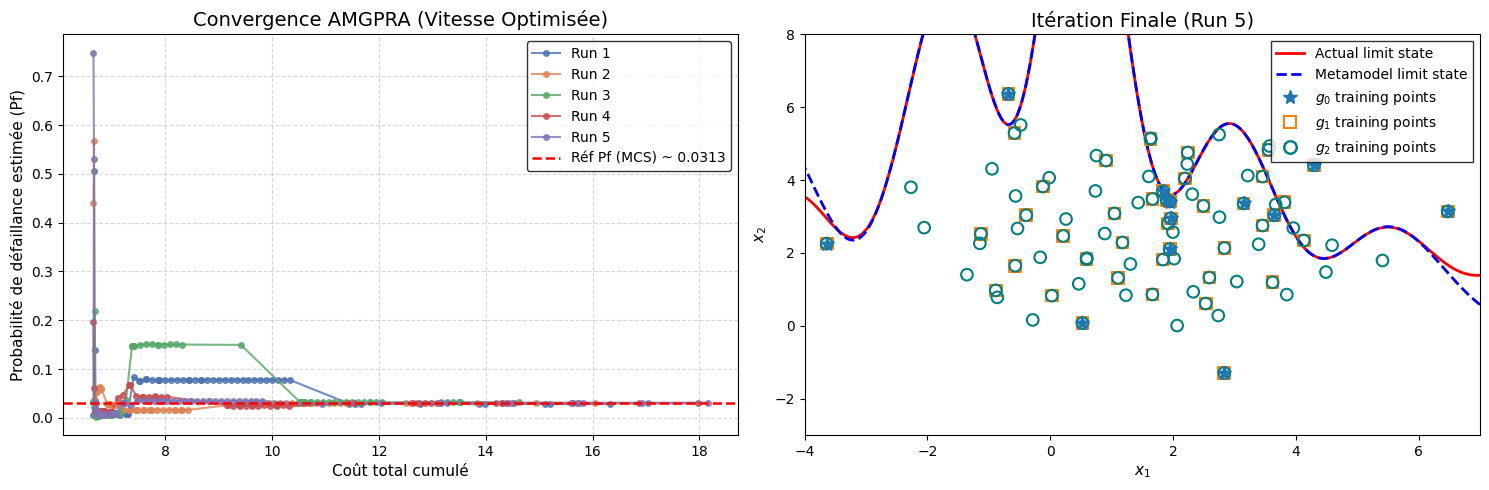

In [ ]:
#5.1. 3 fidelities

def g0(X):
    x1, x2 = X[:, 0], X[:, 1]
    return (2.0 - ((x1**2 + 4.0) * (x2 - 1.0)) / 20.0 + np.sin(5.0 * x1 / 2.0)).reshape(-1, 1)

def g1(X):
    x1, x2 = X[:, 0], X[:, 1]
    return g0(X) - np.sin(5.0 * x1 / 22.0 + 5.0 * x2 / 44.0 + 5.0 / 4.0).reshape(-1, 1)

def g2(X):
    x1, x2 = X[:, 0], X[:, 1]
    return g0(X) - np.sin(5.0 * x1 / 11.0 + 5.0 * x2 / 22.0 + 35.0 / 11.0).reshape(-1, 1)


if __name__ == "__main__":
    n_runs = 5
    n_train, n_eval = 10000, 1000000

    functions = [g0, g1, g2]
    costs = [1.0, 0.1, 0.01]
    xlimits = np.array([[-4.0, 7.0], [-3.0, 8.0]])

    all_pfs, all_costs = [], []
    all_pf_h, all_cost_h = [], []

    for run_idx in range(n_runs):
        print(f"\n--- RUN AMGPRA {run_idx + 1}/{n_runs} ---")
        S_train = np.column_stack([np.random.normal(1.5, 1.0, n_train), np.random.normal(2.5, 1.0, n_train)])

        solver = AMGPRA(functions, costs, xlimits, S_candidate=S_train, n_init=6, eff_stop=0.001)
        solver.run()

        S_eval = np.column_stack([np.random.normal(1.5, 1.0, n_eval), np.random.normal(2.5, 1.0, n_eval)])
        mu_eval, _ = solver.model.predict(S_eval)
        final_pf = np.sum(mu_eval <= 0) / n_eval

        all_pfs.append(final_pf)
        all_costs.append(solver.total_cost)
        all_pf_h.append(solver.pf_history)
        all_cost_h.append(solver.cost_history)
        last_solver = solver

    print("\n=========================================")
    print(f"Pf moyen   : {np.mean(all_pfs):.4e} (Réf : ~3.14e-02)")
    print(f"Coût moyen : {np.mean(all_costs):.2f} (Réf : ~12.32 pour 3 fidélités)")


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3']

    for i in range(n_runs):
        ax1.plot(all_cost_h[i], all_pf_h[i], marker='o', markersize=4,
                 linestyle='-', linewidth=1.5, color=colors[i], alpha=0.8, label=f'Run {i+1}')

    ax1.axhline(y=0.0313, color='red', linestyle='--', linewidth=1.8, label='Réf Pf (MCS) ~ 0.0313')
    ax1.set_xlabel('Coût total cumulé', fontsize=11)
    ax1.set_ylabel('Probabilité de défaillance estimée (Pf)', fontsize=11)
    ax1.set_title('Convergence AMGPRA (Vitesse Optimisée)', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(frameon=True, edgecolor='black', fontsize=10)

    x1_grid = np.linspace(xlimits[0, 0], xlimits[0, 1], 300)
    x2_grid = np.linspace(xlimits[1, 0], xlimits[1, 1], 300)
    X1, X2 = np.meshgrid(x1_grid, x2_grid)
    Xgrid = np.column_stack([X1.ravel(), X2.ravel()])

    G_true = g0(Xgrid).reshape(X1.shape)
    mu_hf, _ = last_solver.model.predict(Xgrid)
    G_pred = mu_hf.reshape(X1.shape)

    ax2.contour(X1, X2, G_true, levels=[0.0], colors='red', linewidths=2.0)
    ax2.contour(X1, X2, G_pred, levels=[0.0], colors='blue', linewidths=2.0, linestyles='--')

    markers = ['*', 's', 'o']
    for fid in range(len(last_solver.xt)):
        Xfid = last_solver.xt[fid]
        if Xfid is None or len(Xfid) == 0:
            continue

        if markers[fid] == '*':
            ax2.scatter(Xfid[:, 0], Xfid[:, 1], marker=markers[fid], s=100,
                        c='tab:blue', linewidths=1.2, zorder=5)
        else:
            edge_c = 'tab:orange' if fid == 1 else 'teal'
            ax2.scatter(Xfid[:, 0], Xfid[:, 1], marker=markers[fid], s=70,
                        facecolors='none', edgecolors=edge_c, linewidths=1.5, zorder=4)

    legend_elements = [
        Line2D([0], [0], color='red', lw=2, label='Actual limit state'),
        Line2D([0], [0], color='blue', lw=2, ls='--', label='Metamodel limit state'),
        Line2D([0], [0], marker='*', color='tab:blue', lw=0, markersize=10, label=r'$g_0$ training points'),
        Line2D([0], [0], marker='s', color='tab:orange', markerfacecolor='none', lw=0, markersize=8, markeredgewidth=1.5, label=r'$g_1$ training points'),
        Line2D([0], [0], marker='o', color='teal', markerfacecolor='none', lw=0, markersize=9, markeredgewidth=1.8, label=r'$g_2$ training points'),
    ]
    ax2.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=False, edgecolor='black', fontsize=10)

    ax2.set_xlabel(r"$x_1$", fontsize=11)
    ax2.set_ylabel(r"$x_2$", fontsize=11)
    ax2.set_xlim(xlimits[0, 0], xlimits[0, 1])
    ax2.set_ylim(xlimits[1, 0], xlimits[1, 1])
    ax2.set_title(f"Itération Finale (Run 5)", fontsize=14)

    plt.tight_layout()
    plt.show()

---
---
---
SOLAR
---
---
---

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
%cd /content/drive/MyDrive
!git clone https://github.com/bbopt/solar.git
%cd solar

!g++ -O3 -o solar_linux src/*.cpp
!./solar_linux -h

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive
Cloning into 'solar'...
remote: Enumerating objects: 2421, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 2421 (delta 157), reused 131 (delta 130), pack-reused 2235 (from 2)
Receiving objects: 100% (2421/2421), 234.14 MiB | 7.56 MiB/s, done.
Resolving deltas: 100% (661/661), done.
Updating files: 100% (1589/1589), done.
/content/drive/MyDrive/solar
src/HeatExchanger.cpp: In member function ‘double HeatExchanger::fComputeRequiredMoltenSaltMassFlow(double, double, double)’:
src/HeatExchanger.cpp:228:8: error: ‘isnan’ was not declared in this scope; did you mean ‘std::isnan’?
  228 |   if ( isnan(T_in_ms) || isnan(T_out_ms) ) {
      |        ^~~~~
      |        std::isnan
In file included from src/MoltenSalt.hpp:28,
                 from src/HeatExchanger.hpp:27,
     

In [ ]:
%cd /content/drive/MyDrive/solar
!sed -i 's/isnan/std::isnan/g' src/HeatExchanger.cpp
!g++ -O3 -std=c++11 -o solar_linux src/*.cpp

/content/drive/MyDrive/solar
✅ Compilation réussie !

Run simulation: solar pb_id x.txt -seed=S -fid=F -rep=R -v (optional)

 pb_id: Problem instance (see list of problems below)

 x.txt: Point at which the simulator is evaluated
        Values separated with spaces
        It is possible to specify several points: Use one line for each

    -v: Verbose option

     S: Random seed:
          Some SOLAR instances are stochastic. This parameter impacts the value of stochastic outputs
          The seed is a natural integer
          If SOLAR is run twice at the same point with the same seed, it will give the same outputs
          The default value is 0
          Use -seed=diff to let SOLAR use a different random seed each time
          The random number generator can be validated by running 'solar -check'

     F: Fidelity of the simulator
          Real value in [0;1]
          Default: 1.0 (full fidelity), which corresponds to the "true blackbox", or the "truth"
          Any value i

Calcul pour seuil +0.1% (tau=42.4591)
   -> Pf estimée: 3.9500e-02
Calcul pour seuil +1% (tau=42.8408)
   -> Pf estimée: 7.2000e-02
Calcul pour seuil +5% (tau=44.5375)
   -> Pf estimée: 1.2800e-02
Calcul pour seuil +10% (tau=46.6583)
   -> Pf estimée: 1.0000e-03
Calcul pour seuil +20% (tau=50.9000)
   -> Pf estimée: 0.0000e+00
Calcul pour seuil +30% (tau=55.1417)
   -> Pf estimée: 0.0000e+00
Calcul pour seuil +60% (tau=67.8667)
   -> Pf estimée: 0.0000e+00


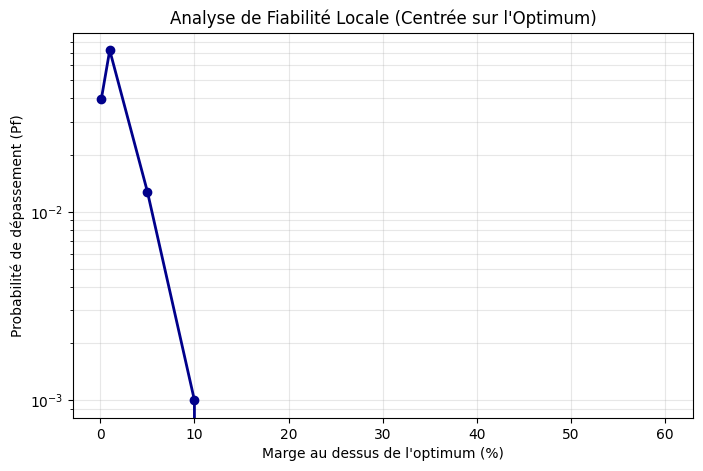

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from smt.applications import MFK

X_OPT = np.array([994.999948, 34.201832, 24.271669, 0.024489, 0.010019])
F_STAR = 42.416671
FIDELITIES = [1.0, 0.5]
COSTS = [1.0, 0.45]

PERCENTAGES = [0.1, 1, 5, 10, 20, 30, 60]

std_dev = 0.01 * X_OPT
N_MC = 10000
S_candidate = np.random.normal(loc=X_OPT, scale=std_dev, size=(N_MC, 5))

class MultiFidelitySolver:
    def __init__(self, tau):
        self.tau = tau
        self.model = MFK(print_global=False, hyper_opt='Cobyla', poly='constant')
        self.xt = [None, None]
        self.yt = [None, None]

    def add_point(self, x, fid_idx):
        val_physique = call_solar(x, FIDELITIES[fid_idx])
        val_fiabilite = self.tau - val_physique

        x_scaled = x.reshape(1, -1)
        if self.xt[fid_idx] is None:
            self.xt[fid_idx] = x_scaled
            self.yt[fid_idx] = np.array([[val_fiabilite]])
        else:
            self.xt[fid_idx] = np.vstack([self.xt[fid_idx], x_scaled])
            self.yt[fid_idx] = np.vstack([self.yt[fid_idx], val_fiabilite])

    def train(self):
        for i in range(2):
            name = None if i == 0 else 0
            self.model.set_training_values(self.xt[i], self.yt[i], name=name)
        self.model.options.update({'noise0': [1e-2]})
        self.model.train()

final_results = []

for p in PERCENTAGES:
    tau = F_STAR * (1 + p/100)
    print(f"Calcul pour seuil +{p}% (tau={tau:.4f})")

    solver = MultiFidelitySolver(tau)
    x_init = np.random.normal(loc=X_OPT, scale=std_dev, size=(10, 5))
    for x in x_init:
        solver.add_point(x, 0)
        solver.add_point(x, 1)

    for it in range(15):
        try:
            solver.train()
            mu = solver.model.predict_values(S_candidate)
            sigma = np.sqrt(np.maximum(solver.model.predict_variances(S_candidate), 1e-10))

            u_score = np.abs(mu.flatten()) / np.maximum(sigma.flatten(), 1e-6)
            best_idx = np.argmin(u_score)

            fid = 0 if sigma[best_idx] > 0.1 else 1
            solver.add_point(S_candidate[best_idx], fid)
        except:
            break

    pf_est = np.mean(mu <= 0)
    final_results.append(pf_est)
    print(f"   -> Pf estimée: {pf_est:.4e}")

plt.figure(figsize=(8, 5))
plt.plot(PERCENTAGES, final_results, 'o-', color='darkblue', linewidth=2)
plt.yscale('log')
plt.xlabel("Marge au dessus de l'optimum (%)")
plt.ylabel("Probabilité de dépassement (Pf)")
plt.title("Analyse de Fiabilité Locale (Centrée sur l'Optimum)")
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.show()

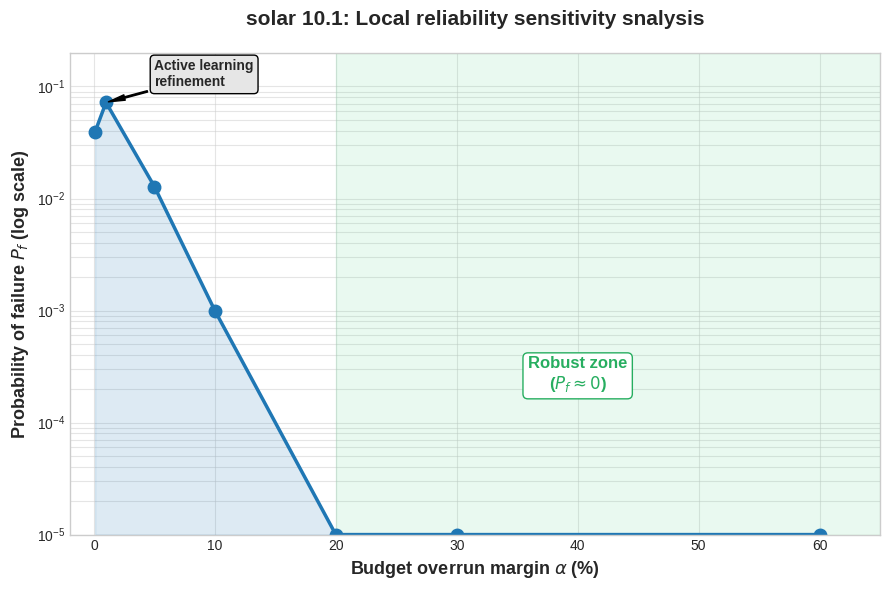

Graphique sauvegardé sous 'solar_reliability_fragility_curve.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

PERCENTAGES = np.array([0.1, 1, 5, 10, 20, 30, 60])
final_results = np.array([3.9500e-02, 7.2000e-02, 1.2800e-02, 1.0000e-03, 0.0, 0.0, 0.0])

df = pd.DataFrame({'margin': PERCENTAGES, 'pf': final_results})
df['pf_plot'] = np.maximum(df['pf'], 1e-5)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(df['margin'], df['pf_plot'], 'o-', color='#1F77B4',
        linewidth=2.5, markersize=9, label='AMGPRA estimated $\hat{P}_f$')

ax.fill_between(df['margin'], 1e-5, df['pf_plot'], color='#1F77B4', alpha=0.15)

ax.set_yscale('log')
ax.set_ylim(1e-5, 2e-1)
ax.set_xlim(-2, 65)

ax.set_xlabel(r"Budget overrun margin $\alpha$ (%)", fontsize=13, fontweight='bold')
ax.set_ylabel(r"Probability of failure $P_f$ (log scale)", fontsize=13, fontweight='bold')
ax.set_title("solar 10.1: Local reliability sensitivity snalysis", fontsize=15, fontweight='bold', pad=20)

ax.grid(True, which="both", ls="-", alpha=0.5)

ax.annotate('Active learning\nrefinement', xy=(1, 7.2e-2), xytext=(5, 1e-1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4),
            fontsize=10, fontweight='bold', bbox=dict(boxstyle="round", fc="0.9"))

ax.axvspan(20, 65, color='#2ECC71', alpha=0.1)
ax.text(40, 2e-4, r"Robust zone" + "\n" + r"($P_f \approx 0$)", color='#27AE60',
        fontsize=12, fontweight='bold', ha='center',
        bbox=dict(boxstyle="round", fc="w", ec="#27AE60"),
        usetex=False)

plt.tight_layout()
plt.savefig('solar_reliability_fragility_curve.png', dpi=300)
plt.show()

print("Graphique sauvegardé sous 'solar_reliability_fragility_curve.png'")

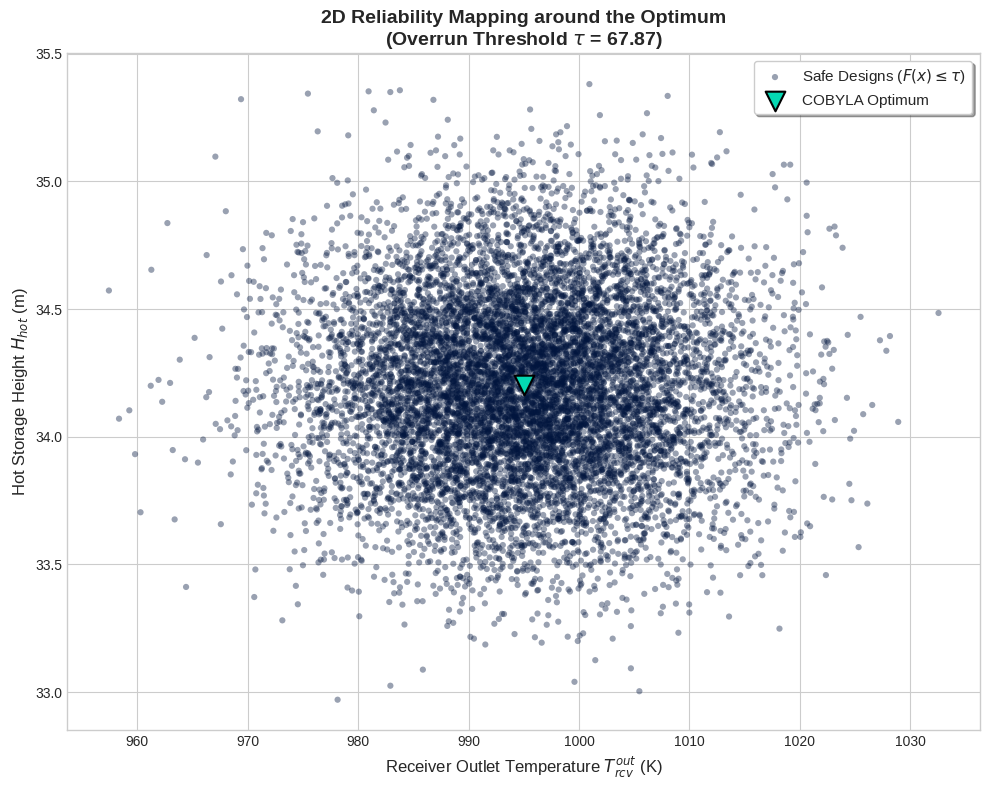

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

mu_final = solver.model.predict_values(S_candidate)

safe_idx = np.where(mu_final.flatten() > 0)[0]
fail_idx = np.where(mu_final.flatten() <= 0)[0]

dim_x = 0
dim_y = 1

plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')

plt.scatter(S_candidate[safe_idx, dim_x], S_candidate[safe_idx, dim_y],
            c='#01153E', alpha=0.4, s=20, label='Safe Designs ($F(x) \leq \\tau$)', edgecolors='none')

if len(fail_idx) > 0:
    plt.scatter(S_candidate[fail_idx, dim_x], S_candidate[fail_idx, dim_y],
                c='#E74C3C', alpha=0.8, s=30, label='Failure Zone ($F(x) > \\tau$)', edgecolors='none')

plt.scatter(X_OPT[dim_x], X_OPT[dim_y], color='#04D8B2', marker='v',
            s=200, edgecolors='black', linewidths=1.5, label='COBYLA Optimum', zorder=10)

plt.xlabel(r"Receiver Outlet Temperature $T_{rcv}^{out}$ (K)", fontsize=12)
plt.ylabel(r"Hot Storage Height $H_{hot}$ (m)", fontsize=12)
plt.title(f"2D Reliability Mapping around the Optimum\n(Overrun Threshold $\\tau$ = {solver.tau:.2f})",
          fontsize=14, fontweight='bold')

plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=11)
plt.tight_layout()
plt.savefig('solar_2d_map.png', dpi=300)
plt.show()

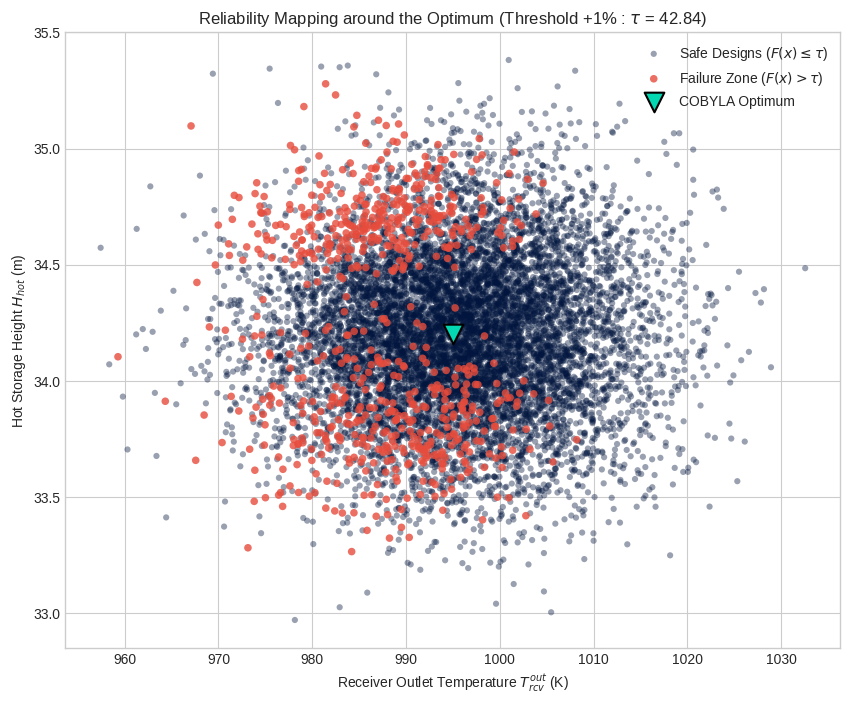

In [ ]:
tau_1_percent = F_STAR * (1 + 1/100)

mu_original = solver.model.predict_values(S_candidate)
tau_old = solver.tau
mu_1_percent = tau_1_percent - (tau_old - mu_original)

safe_idx = np.where(mu_1_percent.flatten() > 0)[0]
fail_idx = np.where(mu_1_percent.flatten() <= 0)[0]

plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')

plt.scatter(S_candidate[safe_idx, 0], S_candidate[safe_idx, 1],
            c='#01153E', alpha=0.4, s=20, label='Safe Designs ($F(x) \leq \\tau$)', edgecolors='none')

if len(fail_idx) > 0:
    plt.scatter(S_candidate[fail_idx, 0], S_candidate[fail_idx, 1],
                c='#E74C3C', alpha=0.8, s=30, label='Failure Zone ($F(x) > \\tau$)', edgecolors='none')

plt.scatter(X_OPT[0], X_OPT[1], color='#04D8B2', marker='v',
            s=200, edgecolors='black', linewidths=1.5, label='COBYLA Optimum', zorder=10)

plt.xlabel(r"Receiver Outlet Temperature $T_{rcv}^{out}$ (K)")
plt.ylabel(r"Hot Storage Height $H_{hot}$ (m)")
plt.title(f"Reliability Mapping around the Optimum (Threshold +1% : $\\tau$ = {tau_1_percent:.2f})")
plt.legend()
plt.show()

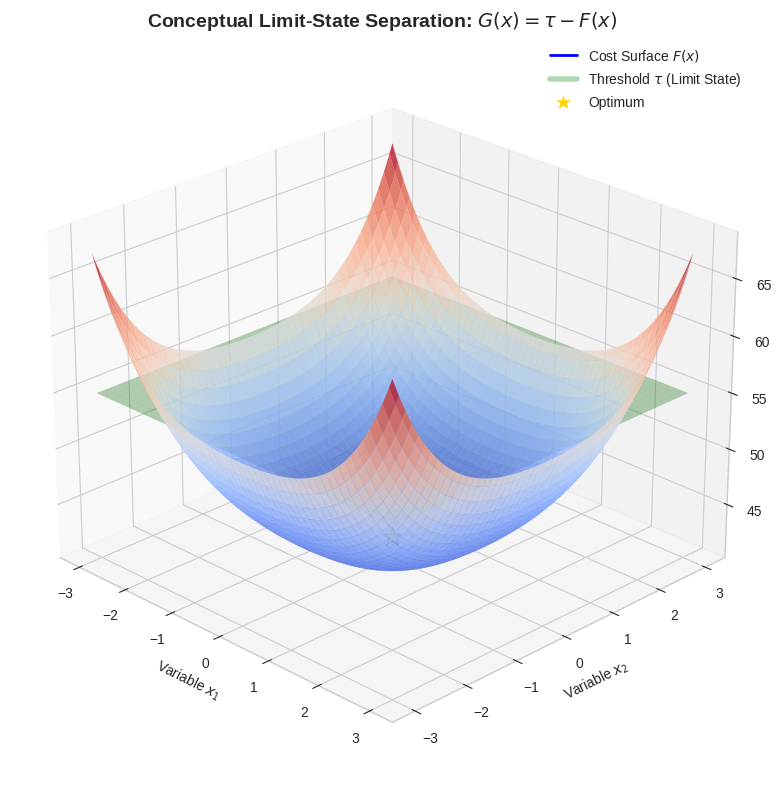

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def cost_surface(x, y):
    return 42 + 0.5*(x**2 + y**2) + 0.1*(x**4 + y**4)

x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = cost_surface(X, Y)

tau = 55

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, alpha=0.8,
                       linewidth=0, antialiased=True, zorder=1)


Z_tau = np.full_like(Z, tau)
ax.plot_surface(X, Y, Z_tau, color='green', alpha=0.3, label=r'Threshold $\tau$', zorder=2)

ax.scatter(0, 0, 42, color='gold', s=200, marker='*', edgecolors='black',
           label='Optimum $F(x_{opt})$', zorder=5)

ax.set_xlabel('Variable $x_1$', fontsize=10)
ax.set_ylabel('Variable $x_2$', fontsize=10)
ax.set_zlabel('Cost $F(x)$', fontsize=10)
ax.set_title(r'Conceptual Limit-State Separation: $G(x) = \tau - F(x)$', fontsize=14, fontweight='bold')

ax.view_init(elev=25, azim=-45)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Cost Surface $F(x)$'),
    Line2D([0], [0], color='green', alpha=0.3, lw=4, label=r'Threshold $\tau$ (Limit State)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold', markersize=15, label='Optimum')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('conceptual_limit_state_3d.png', dpi=300)
plt.show()